In [37]:
import contextlib
import time
import qutip as qt


import numpy as np
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt

from qutip import (
    about, basis, brmesolve, destroy, expect, liouvillian,
    qeye, sigmax, sigmaz, spost, spre, tensor
)
from qutip.core.environment import (
    DrudeLorentzEnvironment, ExponentialBosonicEnvironment, system_terminator
)
from qutip.solver.heom import HEOMSolver, HSolverDL

%matplotlib inline

### Helpers

In [2]:
def cot(x):
    """Vectorized cotangent of x."""
    return 1.0 / np.tan(x)

def dl_matsubara_params(lam, gamma, T, nk):
    """Calculation of the real and imaginary expansions of the Drude-Lorenz
    correlation functions.
    """
    ckAR = [lam * gamma * cot(gamma / (2 * T))]
    ckAR.extend(
        8 * lam * gamma * T * np.pi * k * T / (
            (2 * np.pi * k * T) ** 2 - gamma**2
        )
        for k in range(1, nk + 1)
    )
    vkAR = [gamma]
    vkAR.extend(2 * np.pi * k * T for k in range(1, nk + 1))

    ckAI = [lam * gamma * (-1.0)]
    vkAI = [gamma]

    return ckAR, vkAR, ckAI, vkAI

def plot_result_expectations(plots, axes=None):
    """Plot the expectation values of operators as functions of time.

    Each plot in plots consists of (solver_result, measurement_operation,
    color, label).
    """
    if axes is None:
        fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 8))
        fig_created = True
    else:
        fig = None
        fig_created = False

    # add kw arguments to each plot if missing
    plots = [p if len(p) == 5 else p + ({},) for p in plots]
    for result, m_op, color, label, kw in plots:
        exp = np.real(expect(result.states, m_op))
        kw.setdefault("linewidth", 2)
        axes.plot(result.times, exp, color, label=label, **kw)

    if fig_created:
        axes.legend(loc=0, fontsize=12)
        axes.set_xlabel("t", fontsize=28)

    return fig

@contextlib.contextmanager
def timer(label):
    """Simple utility for timing functions:

    with timer("name"):
        ... code to time ...
    """
    start = time.time()
    yield
    end = time.time()
    print(f"{label}: {end - start}")

# Default solver options:

default_options = {
    "nsteps": 1500,
    "store_states": True,
    "rtol": 1e-12,
    "atol": 1e-12,
    "method": "vern9",
    "progress_bar": "enhanced",
}

### System and bath definition

In [23]:
# Defining the system Hamiltonian
eps = 0.5  # Energy of the 2-level system.
Del = 1.0  # Tunnelling term
Hsys = 0.5 * eps * sigmaz() + 0.5 * Del * sigmax()

# Initial state of the system.
rho0 = basis(2, 0) * basis(2, 0).dag()

# System-bath coupling (Drude-Lorentz spectral density)
Q = sigmaz()  # coupling operator

# Bath properties:
gamma = 0.5  # cut off frequency
lam = 0.1  # coupling strength
T = 0.5
beta = 1.0 / T

# HEOM parameters
NC = 10  # cut off parameter for the bath
Nk = 4  # terms in the Matsubara expansion of the correlation function

# Times to solve for
tlist = np.linspace(0, 50, 1000)

# Define some operators with which we will measure the system
# 1,1 element of density matrix - corresonding to groundstate
P11p = basis(2, 0) * basis(2, 0).dag()
P22p = basis(2, 1) * basis(2, 1).dag()
# 1,2 element of density matrix  - corresonding to coherence
P12p = basis(2, 0) * basis(2, 1).dag()

### Spectral density

In [24]:
def plot_spectral_density():
    """Plot the Drude-Lorentz spectral density"""
    w = np.linspace(0, 5, 1000)
    J = w * 2 * lam * gamma / (gamma**2 + w**2)

    fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 8))
    axes.plot(w, J, "r", linewidth=2)
    axes.set_xlabel(r"$\omega$", fontsize=28)
    axes.set_ylabel(r"J", fontsize=28)


plot_spectral_density()

Matsubara decomposition

In [25]:
ckAR, vkAR, ckAI, vkAI = dl_matsubara_params(nk=Nk, lam=lam, gamma=gamma, T=T)

In [ ]:
options = {**default_options}

with timer("RHS construction time"):
    env = ExponentialBosonicEnvironment(ckAR, vkAR, ckAI, vkAI)
    HEOMMats = HEOMSolver(Hsys, (env, Q), NC, options=options)

with timer("ODE solver time"):
    resultMats = HEOMMats.run(rho0, tlist)

RHS construction time: 0.03678441047668457
 Total run time:  16.30s*] Elapsed 16.30s / Remaining 00:00:00:00
ODE solver time: 16.30360770225525


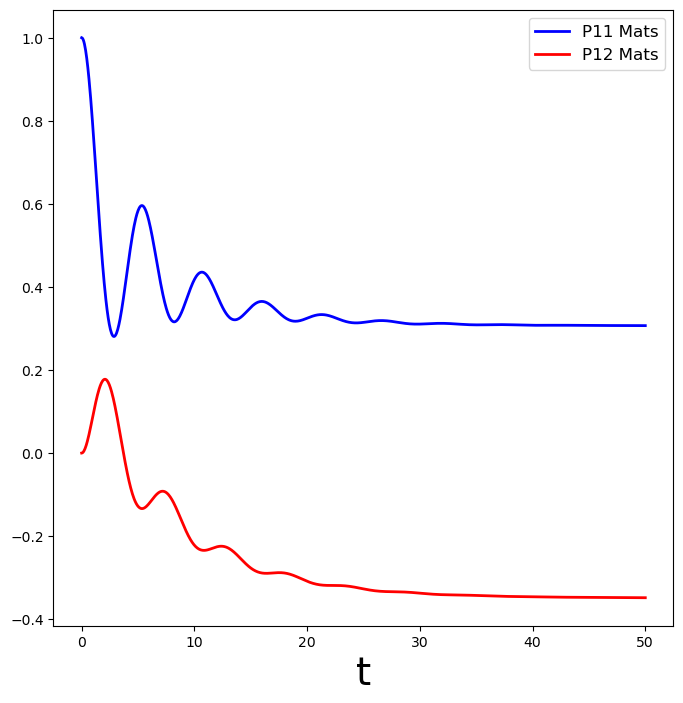

In [27]:
plot_result_expectations(
    [
        (resultMats, P11p, "b", "P11 Mats"),
        (resultMats, P12p, "r", "P12 Mats"),
    ]
)

In [45]:
system_states = resultMats.states
len(system_states)

1000

In [34]:
print(system_states)

[Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[9.99373992e-01+0.j         3.10861398e-04+0.02500558j]
 [3.10861398e-04-0.02500558j 6.26007953e-04+0.j        ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.99749886+0.j         0.00123306+0.04989638j]
 [0.00123306-0.04989638j 0.00250114+0.j        ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.99438311+0.j         0.00274827+0.07456249j]
 [0.00274827-0.07456249j 0.00561689+0.j        ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.99004065+0.j         0.00483483+0.09889892j]
 [0.00483483-0.09889892j 0.00995935+0.j        ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isher

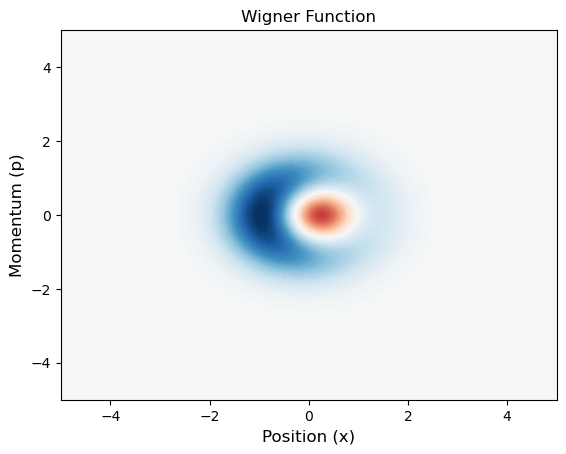

In [46]:
# HEOM 계산 결과에서 특정 상태를 선택 (예: 마지막 상태)
rho_final = system_states[998]

# 위상 공간의 좌표 범위를 지정
xvec = np.linspace(-5, 5, 200) # x축 (위치) 범위
pvec = np.linspace(-5, 5, 200) # p축 (운동량) 범위

# plot_wigner 함수 호출
fig, ax = qt.plot_wigner(rho_final, xvec, pvec, cmap='RdBu')

# 그래프 스타일 설정
ax.set_title("Wigner Function")
ax.set_xlabel("Position (x)")
ax.set_ylabel("Momentum (p)")
plt.show()